part3 - Exploratory Data Analysis

In this section, we will explore the Oxford Flowers 102 dataset by analyzing its distribution, image characteristics, and sample images. This helps us better understand the dataset before training deep learning models.


In [8]:
import os
import sys

PROJECT_ROOT = os.path.abspath("..")

if PROJECT_ROOT not in sys.path:
    sys.path.append(PROJECT_ROOT)

In [9]:
import numpy as np
import matplotlib.pyplot as plt

from PIL import Image
from collections import Counter

In [10]:
from utils.dataset import load_datasets

train_dataset, val_dataset, test_dataset = load_datasets()

In [11]:
#Dataset Overview
print("=" * 50)
print("Oxford Flowers 102 Dataset Overview")
print("=" * 50)

print(f"Training Images   : {len(train_dataset)}")
print(f"Validation Images : {len(val_dataset)}")
print(f"Testing Images    : {len(test_dataset)}")

total = len(train_dataset) + len(val_dataset) + len(test_dataset)

print(f"Total Images      : {total}")

Oxford Flowers 102 Dataset Overview
Training Images   : 1020
Validation Images : 1020
Testing Images    : 6149
Total Images      : 8189


In [12]:
#Class Distribution
labels = train_dataset._labels

counter = Counter(labels)

print(counter)

Counter({0: 10, 1: 10, 2: 10, 3: 10, 4: 10, 5: 10, 6: 10, 7: 10, 8: 10, 9: 10, 10: 10, 11: 10, 12: 10, 13: 10, 14: 10, 15: 10, 20: 10, 16: 10, 17: 10, 18: 10, 19: 10, 21: 10, 22: 10, 23: 10, 24: 10, 25: 10, 26: 10, 27: 10, 28: 10, 29: 10, 30: 10, 31: 10, 32: 10, 33: 10, 34: 10, 35: 10, 36: 10, 37: 10, 38: 10, 39: 10, 40: 10, 41: 10, 42: 10, 43: 10, 44: 10, 45: 10, 46: 10, 47: 10, 48: 10, 49: 10, 50: 10, 51: 10, 52: 10, 53: 10, 54: 10, 55: 10, 56: 10, 57: 10, 58: 10, 59: 10, 60: 10, 61: 10, 62: 10, 63: 10, 64: 10, 65: 10, 66: 10, 67: 10, 68: 10, 69: 10, 70: 10, 71: 10, 72: 10, 73: 10, 74: 10, 75: 10, 76: 10, 77: 10, 78: 10, 79: 10, 80: 10, 81: 10, 82: 10, 83: 10, 84: 10, 85: 10, 86: 10, 87: 10, 88: 10, 89: 10, 90: 10, 91: 10, 92: 10, 93: 10, 94: 10, 95: 10, 96: 10, 97: 10, 98: 10, 99: 10, 100: 10, 101: 10})


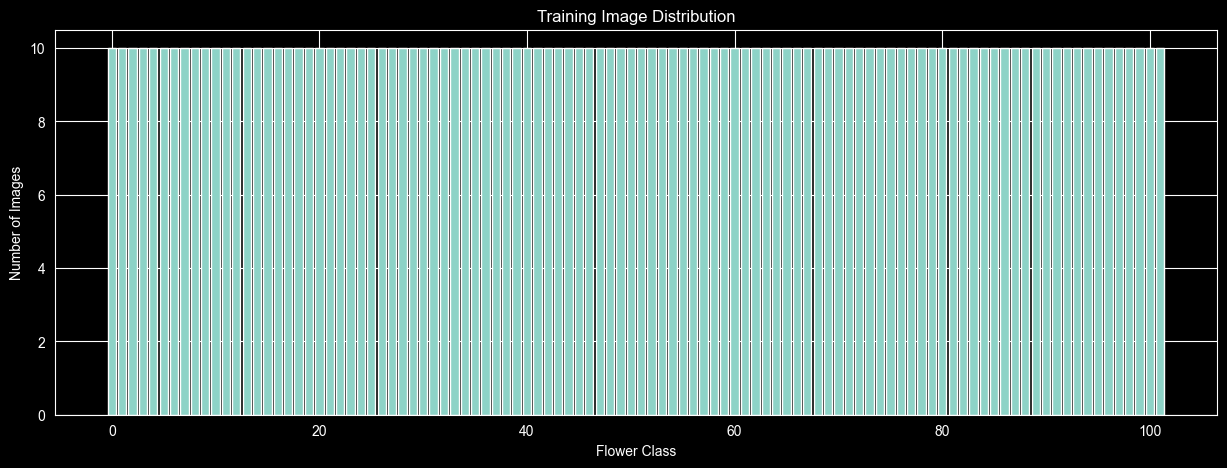

In [13]:
plt.figure(figsize=(15,5))

plt.bar(counter.keys(), counter.values())

plt.xlabel("Flower Class")

plt.ylabel("Number of Images")

plt.title("Training Image Distribution")

plt.show()

The training dataset is evenly distributed across all 102 flower categories. Each category contains approximately the same number of training images, which helps reduce class imbalance during model training.

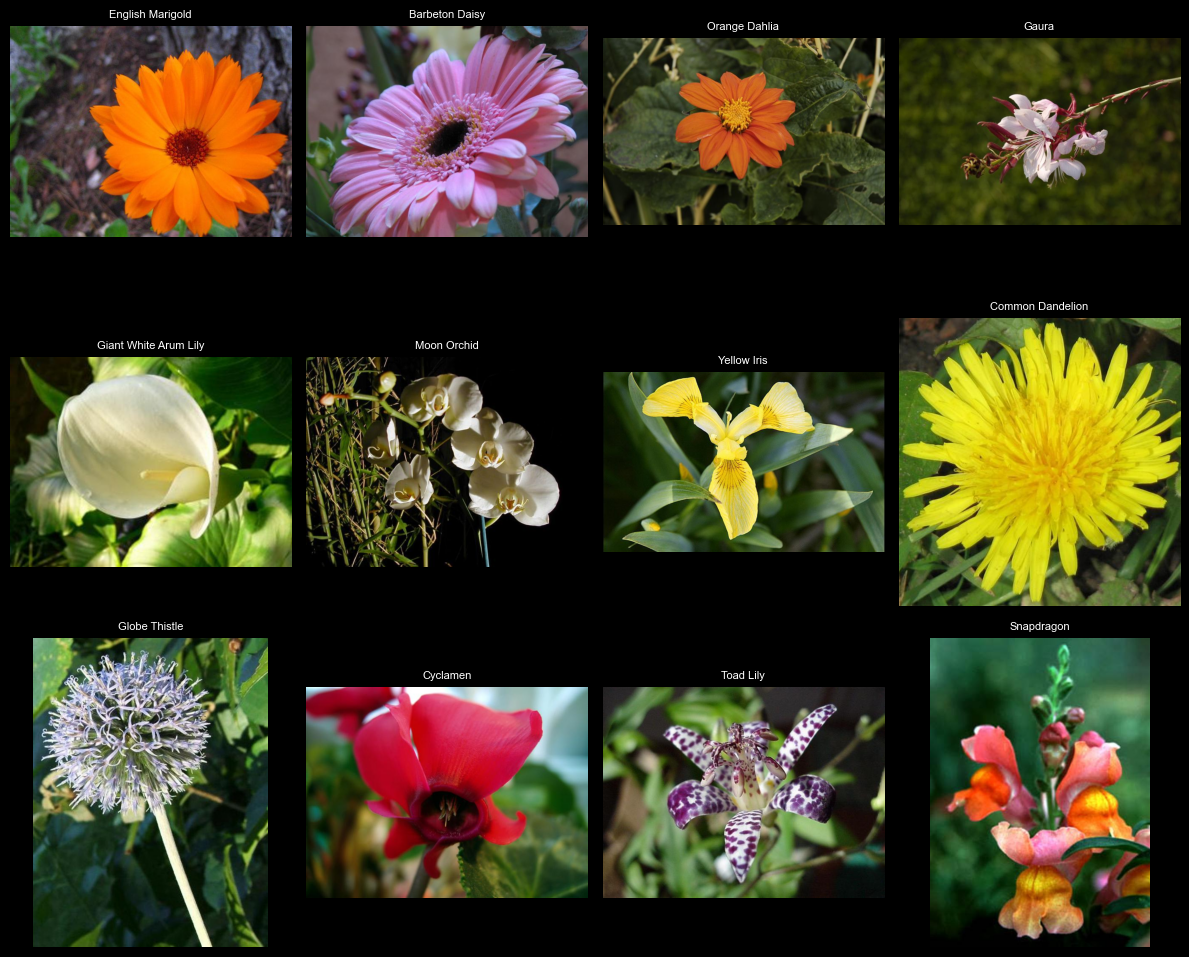

In [28]:
#Sample Images
import random

plt.figure(figsize=(12,10))

for i in range(12):

    idx = random.randint(0, len(train_dataset)-1)

    image, label = train_dataset[idx]

    plt.subplot(3,4,i+1)

    plt.imshow(image)

    from utils.flower_names import FLOWER_NAMES

    plt.title(FLOWER_NAMES[label], fontsize=8)

    plt.axis("off")

plt.tight_layout()

plt.show()

In [15]:
#Image Resolution Analysis
widths = []
heights = []

for image, label in train_dataset:

    widths.append(image.width)
    heights.append(image.height)

In [16]:
#View statistical information
print("Average Width :", np.mean(widths))
print("Average Height:", np.mean(heights))

print("Minimum Width :", np.min(widths))
print("Maximum Width :", np.max(widths))

print("Minimum Height:", np.min(heights))
print("Maximum Height:", np.max(heights))

Average Width : 624.4892156862745
Average Height: 537.7754901960784
Minimum Width : 500
Maximum Width : 919
Minimum Height: 500
Maximum Height: 993


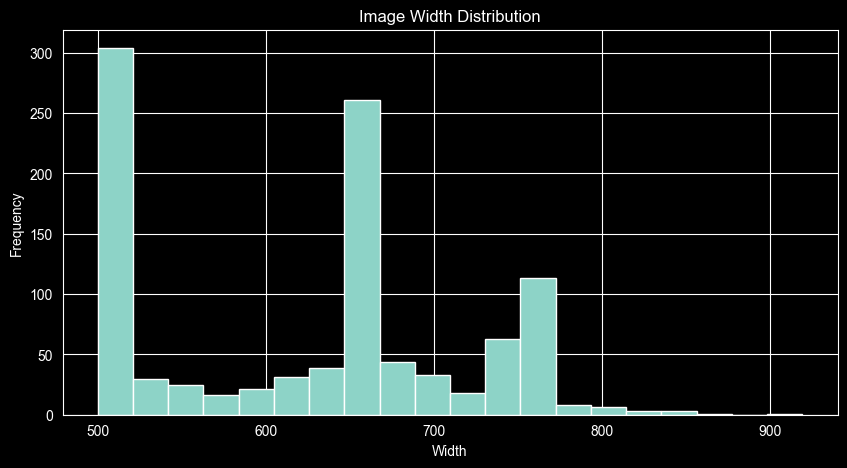

In [17]:
#Drawing width
plt.figure(figsize=(10,5))

plt.hist(widths, bins=20)

plt.title("Image Width Distribution")

plt.xlabel("Width")

plt.ylabel("Frequency")

plt.show()

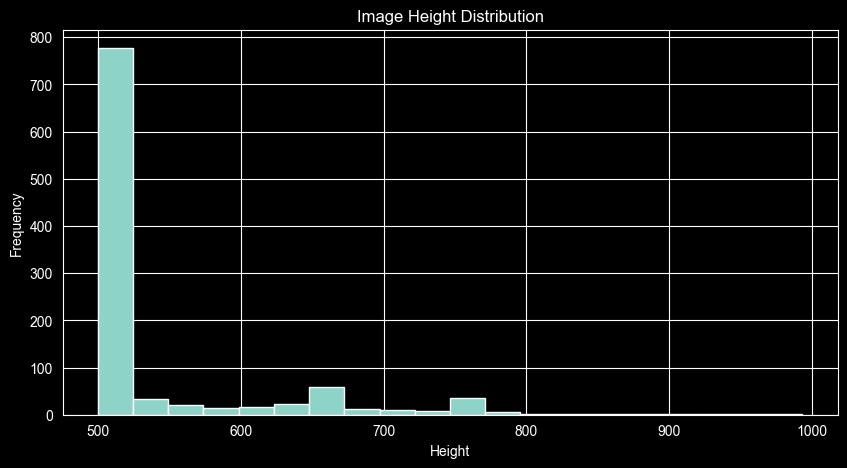

In [18]:
#drawing height
plt.figure(figsize=(10,5))

plt.hist(heights, bins=20)

plt.title("Image Height Distribution")

plt.xlabel("Height")

plt.ylabel("Frequency")

plt.show()

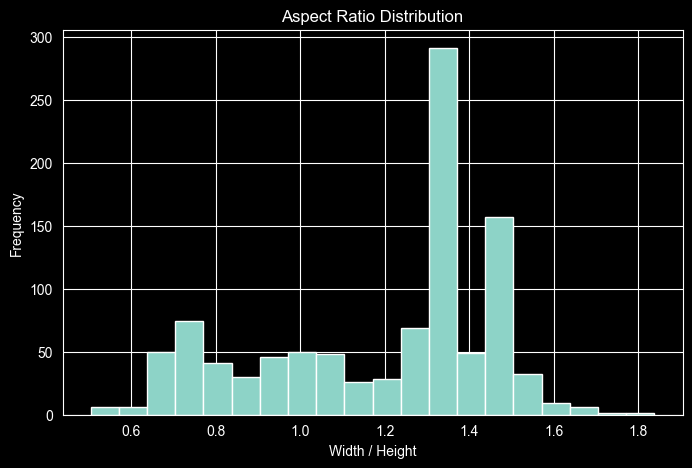

In [19]:
#Aspect Ratio Analysis
ratios = []

for w, h in zip(widths, heights):

    ratios.append(w / h)

plt.figure(figsize=(8,5))

plt.hist(ratios, bins=20)

plt.title("Aspect Ratio Distribution")

plt.xlabel("Width / Height")

plt.ylabel("Frequency")

plt.show()

In [20]:
#Color Mode
modes = Counter()

for image, label in train_dataset:

    modes[image.mode] += 1

print(modes)

Counter({'RGB': 1020})


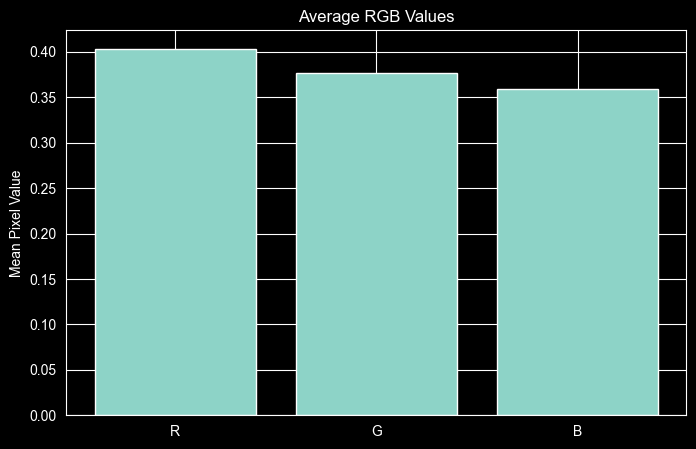

In [26]:
means = []

for i in range(30):

    image, _ = train_dataset[i]

    image = np.array(image) / 255.0

    means.append(image.mean(axis=(0, 1)))

means = np.array(means)

plt.figure(figsize=(8,5))

plt.bar(["R", "G", "B"], means.mean(axis=0))

plt.title("Average RGB Values")

plt.ylabel("Mean Pixel Value")

plt.show()

Summary

The Oxford Flowers 102 dataset contains 8,189 RGB images belonging to 102 flower categories. The training and validation sets are balanced, with each class containing approximately the same number of images. Image resolutions vary significantly, indicating that resizing is required before training. The dataset includes diverse backgrounds, lighting conditions, and viewing angles, making the classification task challenging. Overall, the dataset is suitable for evaluating deep learning models using transfer learning.